# Numeric Cases of Robust Decision Models

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from multiprocess import Pool

In [2]:
import sys
print(sys.executable)


/opt/anaconda3/bin/python


**The following numeric cases require the installation of RSOME 1.3.0 or above.**

In [3]:
import rsome as rso
from rsome import ro
from rsome import cpt_solver as cpt
from rsome import msk_solver as msk

## Estimation Models
### Minimum Volume Confidence Set Estimation

Here, we consider formulation (17) in the paper (i.e. Theorem 7.1):
$$
\begin{align}
\max ~ &(\det (\mathbf{Q}))^{1/L} \\
\text{s.t.}~ &\mathbb{E}_{\hat{\mathbb{P}}} \left[\psi(\|\mathbf{Q}\tilde{\pmb{z}} - \pmb{q} - \mathbf{P}\tilde{\pmb{s}}\|)\right] \leq 1 \\
&\mathbf{Q} \preceq \text{Diag}(\pmb{r})^{-1} \\
&\pmb{q}\in\mathbb{R}^L, \mathbf{P}\in\mathbb{R}^{L\times S}, \mathbf{Q}\in\mathbb{S}_{++}^L
\end{align}
$$

where $\|\cdot\|$ indicates the $L_{p_1}$-norm and we use the following power deviation penalty function:

$$
\psi(r) = \frac{1}{L}r^{p_2}.
$$

We can then implement the following equivalent conic optimization problem using RSOME.
$$
\begin{align}
\max ~ &(\det (\mathbf{Q}))^{1/L} \\
\text{s.t.}~ &\frac{1}{N}\sum\limits_{n=1}^N u_n \leq 1 \\
&(1/L)\cdot v_n^{p_2} \leq u_n & \forall n\in [N] \\
&\|\mathbf{Q}\pmb{z}_n - \pmb{q} - \mathbf{P}\pmb{s}_n \| \leq v_n &\forall n\in [N] \\
&\mathbf{Q} \preceq \text{Diag}(\pmb{r})^{-1} \\
&\pmb{q}\in\mathbb{R}^L, \pmb{u}\in\mathbb{R}^N, \pmb{v}\in\mathbb{R}^N, \mathbf{P}\in\mathbb{R}^{L\times S}, \mathbf{Q}\in\mathbb{S}_{++}^L.
\end{align}
$$

Please note that the formulation above is a general one capable of incorporating side information into the estimation. If no side information is available, the term $\mathbf{P}\pmb{s}_n$ will be removed from the constraints with $L_{p_1}$-norm expressions, and the formulation is equivalent to (9).

In [4]:
def mvcs(z, s=None, r=None, p1=2, p2=2, display=True):
    
    N, L = z.shape #L is the dimension of z, N is the number of in-sample
    
    model = ro.Model()
    q = model.dvar(L)
    u = model.dvar(N)
    v = model.dvar(N)
    Q = model.dvar((L, L))
    
    if s is None:
        side = np.zeros(N)
    else:
        S = s.shape[1] #dimension of vector s
        P = model.dvar((L, S))
        side = s@P.T
    
    model.max(rso.rootdet(Q))
    model.st((1/N) * u.sum() <= 1)
    if isinstance(p2, tuple): 
        model.st((1/L) * rso.power(v, *p2) <= u) #p2 is a tuple, each element of p2 as an input parameter
    else:
        model.st((1/L) * rso.power(v, p2) <= u) #rso.power(v,p2) = v^p2
    l_norm = lambda x: rso.norm(x, p1)  #define a function 'l_norm': p-norm of x
    for n in range(N):
        model.st(l_norm(Q@z[n] - q - side[n]) <= v[n])
    
    if r is not None:
        model.st(Q << np.diag(r ** (-1)))  # regularization constraint            
    
    if display:
        msg = f"Sample data:       {N} records x {L} inputs \n"
        msg += "Side information:  "
        msg += "None\n" if s is None else f"{S} features\n"
        msg += f"Norm type:         l{p1}-norm\n"
        msg += f"Deviation penalty: power={p2}\n"
        print(msg)
        print(model.do_math())

    model.solve(cpt, display=display)
    
    if s is None:
        return q.get(), Q.get()                             # outputs with no side information
    else:
        return q.get(), P.get(), Q.get()                    # outputs with inside information
    

### Estimation for Asymmetric Confidence Set

#### An SDP problem for solving $\mathbf{Q}$ and $\pmb{q}$
Given fixed values of $\pmb{\sigma}_1$ and $\pmb{\sigma}_2$, the following semidefinite programming problem is equivalent to (28) 

$$
\begin{align}
\min~&(\det (\mathbf{Q}))^{1/L} \\
\text{s.t.}~ &\frac{1}{N}\sum\limits_{n=1}^N h_n \leq 1 \\
&(1/L)\cdot g_n^{p_2} \leq h_n & \forall n\in [N] \\
&\pmb{u}_{1n} \geq \text{Diag}(\pmb{\sigma}_1)^{-1}(\mathbf{Q}\pmb{z}_n - \pmb{q})&\forall n\in [N]\\
&\pmb{u}_{1n} \geq \pmb{0}&\forall n\in [N]\\
&\pmb{u}_{2n} \geq -\text{Diag}(\pmb{\sigma}_2)^{-1}(\mathbf{Q}\pmb{z}_n - \pmb{q})&\forall n\in [N]\\
&\pmb{u}_{2n} \geq \pmb{0}&\forall n\in [N]\\
&\|\pmb{u}_{1n} + \pmb{u}_{2n} \| \leq g_{n} &\forall n\in [N] \\
&\mathbf{Q} \preceq \text{Diag}(\pmb{r})^{-1} \\
&\pmb{q}\in\mathbb{R}^L, \pmb{h}\in\mathbb{R}^N, \pmb{g}\in\mathbb{R}^N, \pmb{u} \in \mathbb{R}^{2\times N \times L}, \mathbf{Q}\in\mathbb{S}_{++}^L.
\end{align}
$$

In [1]:
def qq_prob(z, sigma1, sigma2, s=None, r=None, p1=2, p2=2, display=True):
    
    N, L = z.shape
    
    model = ro.Model()
    q = model.dvar(L)
    h = model.dvar(N)
    g = model.dvar(N)
    u = model.dvar((2, N, L))
    Q = model.dvar((L, L))
    
    if s is None:
        side = np.zeros(N)
    else:
        S = s.shape[1]
        P = model.dvar((L, S))
        side = s@P.T

    model.max(rso.rootdet(Q))
    model.st((1/N) * h.sum() <= 1)
    model.st((1/L) * rso.power(g, p2) <= h)
    l_norm = lambda x: rso.norm(x, p1)                      # p-norm of x
    for n in range(N):
        model.st(u[0, n] >= np.diag(1/sigma1)@(Q@z[n] - q - side[n]))
        model.st(u[1, n] >= -np.diag(1/sigma2)@(Q@z[n] - q - side[n]))
        model.st(l_norm(u[0, n] + u[1, n]) <= g[n])
    model.st(u >= 0)
    
    if r is not None:
        model.st(Q << np.diag(r ** (-1)))                   # regularization constraint    
        
    model.solve(cpt, display=display)
    
    if s is None:
        return q.get(), Q.get()
    else:
        return q.get(), P.get(), Q.get()

#### An SOCP problem for solving $\pmb{\sigma}_1$ and $\pmb{\sigma}_2$

Given fixed values of $\mathbf{Q}$ and $\pmb{q}$, the following conic optimization problem is equivalent to (29):

$$
\begin{align}
\max~&\left(\prod_{l\in [L]} t_l\right)^{1/L} \\
\text{s.t.}~ &\frac{1}{N}\sum\limits_{n=1}^N h_n \leq 1 \\
&(1/L)\cdot g_n^{p_2} \leq h_n & \forall n\in [N] \\
&\pmb{u}_{1n} \geq \text{Diag}(\pmb{v}_1)(\mathbf{Q}\pmb{z}_n - \pmb{q})&\forall n\in [N]\\
&\pmb{u}_{1n} \geq \pmb{0}&\forall n\in [N]\\
&\pmb{u}_{2n} \geq -\text{Diag}(\pmb{v}_2)(\mathbf{Q}\pmb{z}_n - \pmb{q})&\forall n\in [N]\\
&\pmb{u}_{2n} \geq \pmb{0}&\forall n\in [N]\\
&\|\pmb{u}_{1n} + \pmb{u}_{2n} \| \leq g_{n} &\forall n\in [N] \\
&2v_{1l} w_{1l} \geq t_l^2 &\forall l \in [L] \\
&2v_{2l} w_{2l} \geq t_l^2 &\forall l \in [L] \\
&t_l \geq w_{1l} + w_{2l} &\forall l \in [L]\\
&\pmb{t}, \pmb{v}_1, \pmb{v}_2, \pmb{w}_1, \pmb{w}_2 \in \mathbb{R}_+^L, \pmb{h}\in\mathbb{R}^N, \pmb{g}\in\mathbb{R}^N, \pmb{u} \in \mathbb{R}^{2\times N \times L}.
\end{align}
$$

In [2]:
def sigma_prob(z, Q, q, side=None, p1=2, p2=2, display=True):
    
    N, L = z.shape
    
    model = ro.Model()
    t = model.dvar(L)
    v1 = model.dvar(L)
    v2 = model.dvar(L)
    w1 = model.dvar(L)
    w2 = model.dvar(L)
    h = model.dvar(N)
    g = model.dvar(N)
    u = model.dvar((2, N, L))
    
    if side is None:
        side = np.zeros(N)
    
    model.max(rso.gmean(t))
    model.st((1/N) * h.sum() <= 1)
    model.st((1/L) * rso.power(g, p2) <= h)
    l_norm = lambda x: rso.norm(x, p1)                      # p-norm of x
    for n in range(N):
        model.st(u[0, n] >= v1* (Q@z[n] - q - side[n]))
        model.st(u[1, n] >= -v2 * (Q@z[n] - q - side[n]))
        model.st(l_norm(u[0, n] + u[1, n]) <= g[n])
    model.st(u >= 0)
    for l in range(L):
        model.st(rso.rsocone(t[l], 2*v1[l], w1[l]))
        model.st(rso.rsocone(t[l], 2*v2[l], w2[l]))
    model.st(t >= w1 + w2)
    model.st(v1 >= 0, v2 >= 0, w1 >= 0, w2 >= 0)
    
    model.solve(cpt, display=display)
    
    return v1.get(), v2.get()

These two problems are solved in each iteration, until 1) if the maximum iteration is reached; or 2) the decrease of the set volume is smaller than a given tolerance. Such a algorithm is implemented as follows.

In [3]:
def mvcs_asymmetric(z, s=None, r=None, p1=2, p2=2,
                    max_iter=100, tol=1e-3, display=True):
    
    N, L = z.shape
    sigma1, sigma2 = np.ones(L), np.ones(L)
    volumn_before = np.inf
    for i in range(max_iter):
        if display:
            print(f'Iteration {i+1}:')
        
        if s is None:
            q, Q = qq_prob(z, sigma1, sigma2, p1=p1, p2=p2, display=display)
            side = None
        else:
            q, P, Q = qq_prob(z, sigma1, sigma2, s, p1=p1, p2=p2, display=display)
            side = s @ P.T

        v1, v2 = sigma_prob(z, Q, q, side, p1=p1, p2=p2, display=display)
        sigma1, sigma2 = 1/v1, 1/v2
        
        volumn_after = 1/np.linalg.det(Q) * np.prod((sigma1 + sigma2)/2)
        if display:
            print(f'The current volumn: {volumn_after}')
            print('')
        gap = abs(volumn_after - volumn_before) / volumn_after
        if gap < tol:
            break
        else:
            volumn_before = volumn_after
    
    if s is None:
        return q, Q, v1, v2
    else:
        return q, P, Q, v1, v2

## Experiments

### Symmetrical confidence set without side information

The dataset `zs` is generated as follows.

In [8]:
m = 30
np.random.seed(1)
zs = np.random.randn(m, 2) # Generate a 2D array (3 rows, 2 columns) normal distribution

Simulate correlation (second column) and ourliers (first column).

In [14]:
zs[:, 1] = zs[:, 0]*0.08 + zs[:, 1] #weak correlation between the first and second column
zs[:, 0] = zs[:, 0] + np.random.binomial(1, 0.01, m) * 10 # simulate the outlier in the first column, binomial distribution function to simulate Bernoulli trials, 1% probability to generate 1 remaining is 0
zs

array([[ 1.62434536,  0.16792936],
       [-0.52817175, -1.32649106],
       [ 0.86540763, -1.88614303],
       [ 1.74481176,  0.07630275],
       [ 0.3190391 , -0.09623161],
       [ 1.46210794, -1.3583289 ],
       [-0.3224172 , -0.53881461],
       [ 1.13376944, -0.55568193],
       [-0.17242821, -0.96062396],
       [ 0.04221375,  0.60307781],
       [-1.10061918,  0.6164265 ],
       [ 0.90159072,  0.93525788],
       [ 0.90085595, -0.251317  ],
       [-0.12289023, -0.99475674],
       [-0.26788808,  0.40176919],
       [-0.69166075, -0.72875069],
       [-0.6871727 , -1.17504854],
       [-0.67124613, -0.33486274],
       [-1.11731035, -0.30189327],
       [ 1.65980218,  1.53874921],
       [-0.19183555, -0.97971003],
       [-0.74715829,  1.33381862],
       [ 0.05080775, -0.61260792],
       [ 0.19091548,  2.19189457],
       [ 0.12015895,  0.67487941],
       [ 0.30017032, -0.20816809],
       [-1.1425182 , -0.89775146],
       [ 9.79110577,  4.48635396],
       [ 0.83898341,

Then we vary the parameters $p_1$ (norm) and $p_2$ (power deviation penalty function) both between one and four, and the fitted confidence sets where $\psi(\|\cdot\|) = 1$ are plotted as follows.

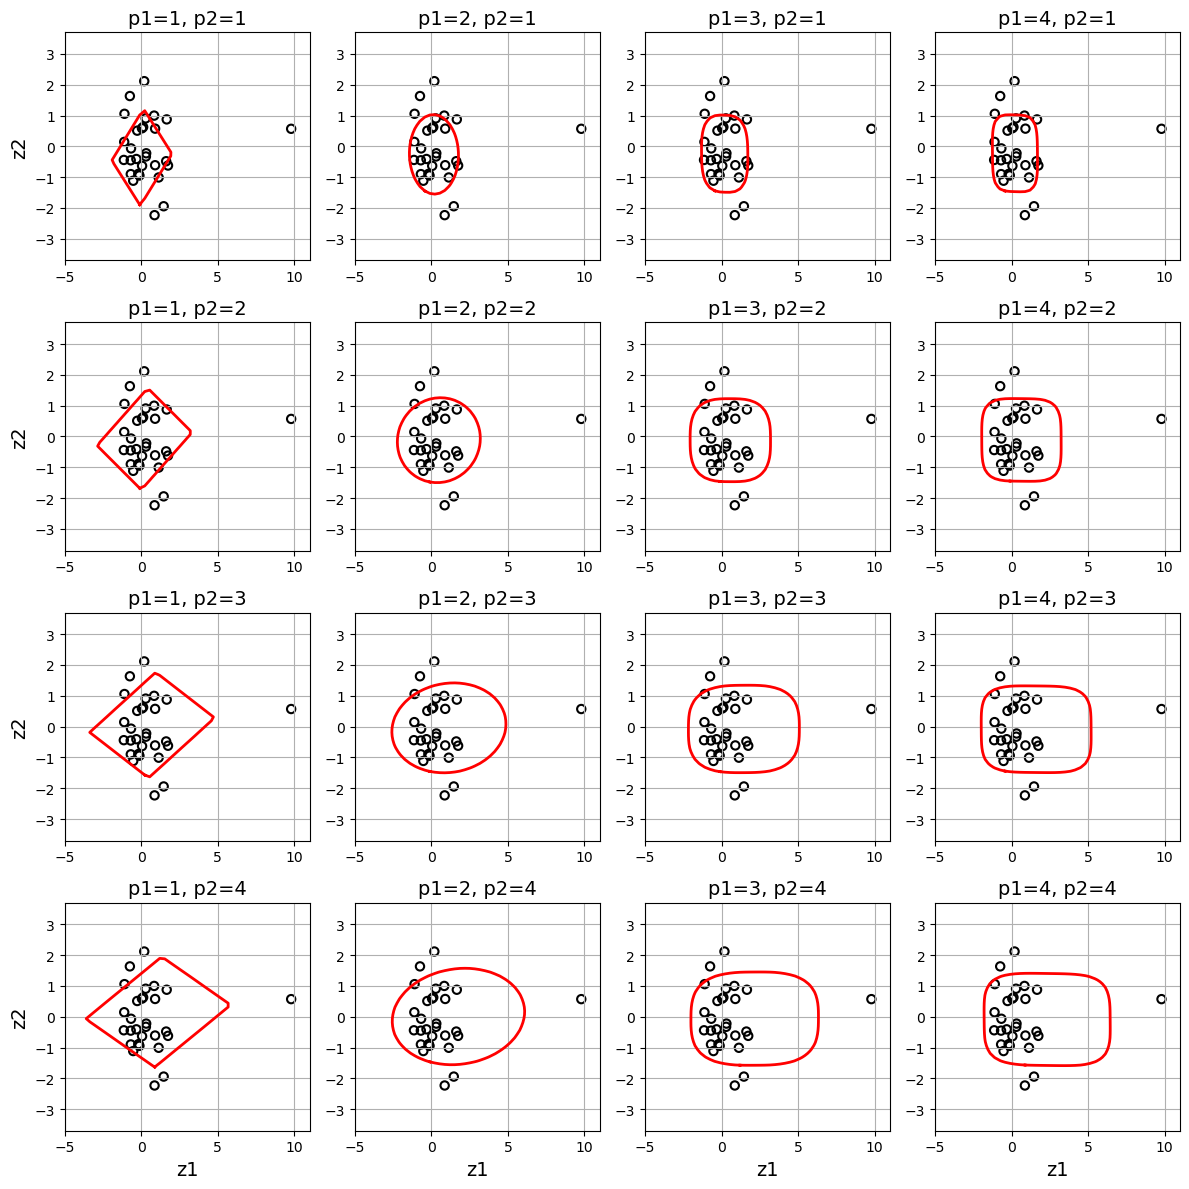

In [10]:
p1_values = range(1, 5)
p2_values = range(1, 5)
color = 'r'

xlim = [-5, 11]
ylim = [-3.7, 3.7]
n1, n2 = 50, 60
z1 = np.linspace(xlim[0], xlim[1], n1) #divided by 50 pieces in [xlim[0], xlim[1]]
z2 = np.linspace(ylim[0], ylim[1], n2)
zz1, zz2 = np.meshgrid(z1, z2) #all meshgrid points
zz = np.concatenate((zz1.flatten()[:, None], #change 1D to 2D, zz1.flatten() returns a 1D
                     zz2.flatten()[:, None]), axis=1) #concatenate by column
fig, axes = plt.subplots(len(p1_values), len(p2_values), 
                        figsize=(len(p1_values)*3, len(p2_values)*3), dpi=100)  

for i, p2 in enumerate(p2_values): #index and value
    for j, p1 in enumerate(p1_values):
        axes[i, j].scatter(zs[:, 0], zs[:, 1], #all row data of 0-th column
                           linewidth=1.5, color='none', edgecolor='k')
        if i == len(p2_values) - 1:
            axes[i, j].set_xlabel('z1', fontsize=14)
        if j == 0:
            axes[i, j].set_ylabel('z2', fontsize=14)
        axes[i, j].set_xlim(xlim)
        axes[i, j].set_ylim(ylim)
        
        q, Q = mvcs(zs, p1=p1, p2=p2, display=False)
        values = np.linalg.norm(zz@Q.T - q, ord=p1, axis=1).reshape(n2, n1)
        ct = axes[i, j].contour(zz1, zz2, (1/2) * (values)**p2, levels=[1], colors=[color]) 
        xydata= ct.allsegs[0][0].copy()
        ct.remove()
        axes[i, j].plot(xydata[:, 0], xydata[:, 1], linewidth=2, color=color)
        axes[i, j].set_title(f'p1={p1}, p2={p2}', fontsize=14)
        axes[i, j].grid()

plt.tight_layout()
plt.show()

### Symmetrical confidence set with side information

In the following code cells, a training dataset of inputs $\pmb{z}$ together with the side information $x$ is created.

In [13]:
m = 20
L = 2
train = pd.DataFrame(np.linspace(0, 2, m), columns=['x'])
train['z1'] = train['x'] ** 2
train['z2'] = 1.5 * train['x'] ** 3 - 1
train

,x,z1,z2
0,0.000000,0.000000,-1.000000
1,0.105263,0.011080,-0.998250
2,0.210526,0.044321,-0.986004
3,0.315789,0.099723,-0.952763
4,0.421053,0.177285,-0.888030
5,0.526316,0.277008,-0.781309
6,0.631579,0.398892,-0.622102
7,0.736842,0.542936,-0.399913
8,0.842105,0.709141,-0.104243
9,0.947368,0.897507,0.275405


In [16]:
zs = train[['z1', 'z2']].values
ss = train[['x']].values # side information


Consider $p_1=2$ and $p_2=2$, a symmetrical confidence set is constructed based on the side information represented by the array `ss`, where the centroid of the set is used as fitted values of various values of $x$, as illustrated below.

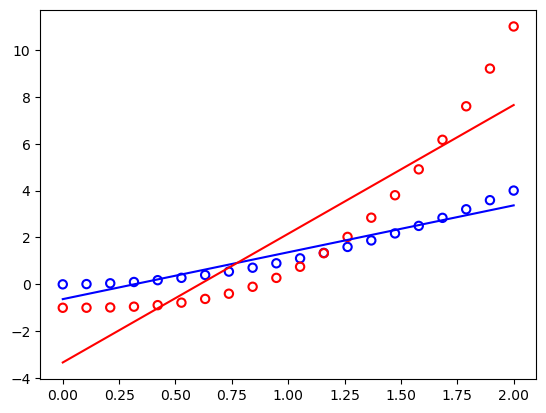

array([[0],
       [2]])

In [ ]:
q, P, Q = mvcs(zs, ss, p1=2, p2=2, display=False)
D = np.linalg.inv(Q)
Zhat = D @ P
zhat0 = D @ q

xx = np.array([0, 2])
zp = zhat0 + xx[:, None]@Zhat.T
plt.scatter(train['x'], train['z1'], linewidth=1.5, color='none', edgecolor='b')
plt.scatter(train['x'], train['z2'], linewidth=1.5, color='none', edgecolor='r')
plt.plot(xx, zp[:, 0], color='b')
plt.plot(xx, zp[:, 1], color='r')
plt.show()

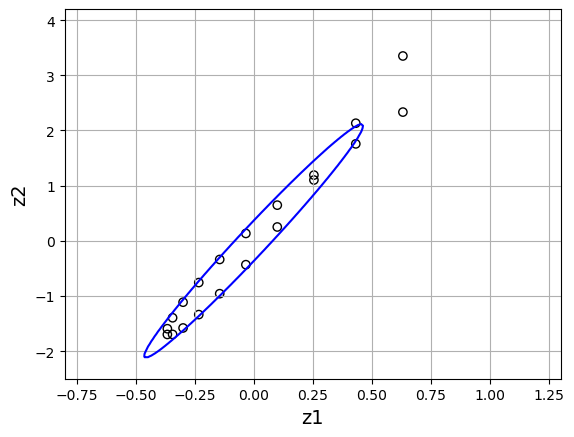

In [18]:
resid = zs - zhat0 - ss@Zhat.T
plt.scatter(resid[:, 0], resid[:, 1], color='none', edgecolor='k')

p1, p2 = 2, 2
xlim = [-0.8, 1.3]
ylim = [-2.5, 4.2]
n1, n2 = 150, 150
z1 = np.linspace(xlim[0], xlim[1], n1)
z2 = np.linspace(ylim[0], ylim[1], n2)
zz1, zz2 = np.meshgrid(z1, z2)
zz = np.concatenate((zz1.flatten()[:, None],
                     zz2.flatten()[:, None]), axis=1)

values = np.linalg.norm(zz@Q.T, ord=p1, axis=1).reshape(n2, n1)
ct = plt.contour(zz1, zz2, (1/2)*(values)**p2, levels=[1], colors=['b'])
plt.xlabel('z1', fontsize=14)
plt.ylabel('z2', fontsize=14)
plt.grid()
plt.show()

Parameters of the predictive model generated from the model are shown below.

In [13]:
zhat0            # Constant terms

array([-0.63157323, -3.3334936 ])

In [14]:
Zhat             # Slop parameters

array([[1.99999572],
       [5.49139339]])

We also fit linear regression models respectively for each input variable $z_i$, it can be seen that when $p_1=2$ and $p_2=2$, parameters from the confidence set coincide with the linear regression models estimated using ordinary least square method.

In [15]:
params = pd.DataFrame({f'z{i+1}': smf.ols(f'z{i+1} ~ x', train).fit().params
                       for i in range(L)})
params

,z1,z2
Intercept,-0.631579,-3.333518
x,2.000000,5.491413


We can also modify the model as follows:
- a variable expressed as $\log(x + 0.1)$ is introduced as a new side information feature;
- the norm is expressed as $L_{2.5}$-norm, so `p1 = (5, 2)`;
- the power deviation penalty is expressed as $\psi(r) = (1/2)r^{3}$, i.e. `p2 = 3`. 

The model is implemented and the fitted values are plotted as follows.

In [16]:
ss = np.concatenate((ss, np.log(train[['x']] + 0.1).values), axis=1)

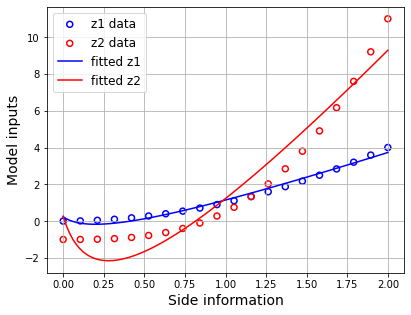

In [17]:
p1 = (5, 2)
p2 = 3
r = np.ones(2) * 0.1
q, P, Q = mvcs(zs, ss, r=r, p1=p1, p2=p2, display=False)
D = np.linalg.inv(Q)
Zhat = D @ P
zhat0 = D @ q

xx = np.concatenate((np.linspace(0, 2, 100)[:, None],
                     np.log(np.linspace(0, 2, 100) + 0.1)[:, None]), axis=1)
zp = zhat0 + xx@Zhat.T
plt.scatter(train['x'], train['z1'], linewidth=1.5, color='none', edgecolor='b', label='z1 data')
plt.scatter(train['x'], train['z2'], linewidth=1.5, color='none', edgecolor='r', label='z2 data')
plt.plot(xx[:, 0], zp[:, 0], color='b', label='fitted z1')
plt.plot(xx[:, 0], zp[:, 1], color='r', label='fitted z2')
plt.xlabel('Side information', fontsize=14)
plt.ylabel('Model inputs', fontsize=14)
plt.legend(fontsize=12)
plt.grid()
plt.show()

### Asymmetric confidence set without side information

The sample data `zs` are generated following skewed distributions in the code cell below.

In [18]:
m = 100
np.random.seed(0)
zs = np.zeros((m, 2))
zs[:,0] = stats.skewnorm.rvs(a=10, loc=0, scale=1, size=m)
zs[:,1] = stats.skewnorm.rvs(a=10, loc=0, scale=1, size=m)
zs[:, 0] = zs[:, 0] + zs[:, 1] * 0.2

Then we very the parameters $p_1$ and $p_2$ both between one and four, and the fitted symmetrical and asymmetrical confidence sets where $\psi(\|\cdot\|) = 1$ are plotted as follows.

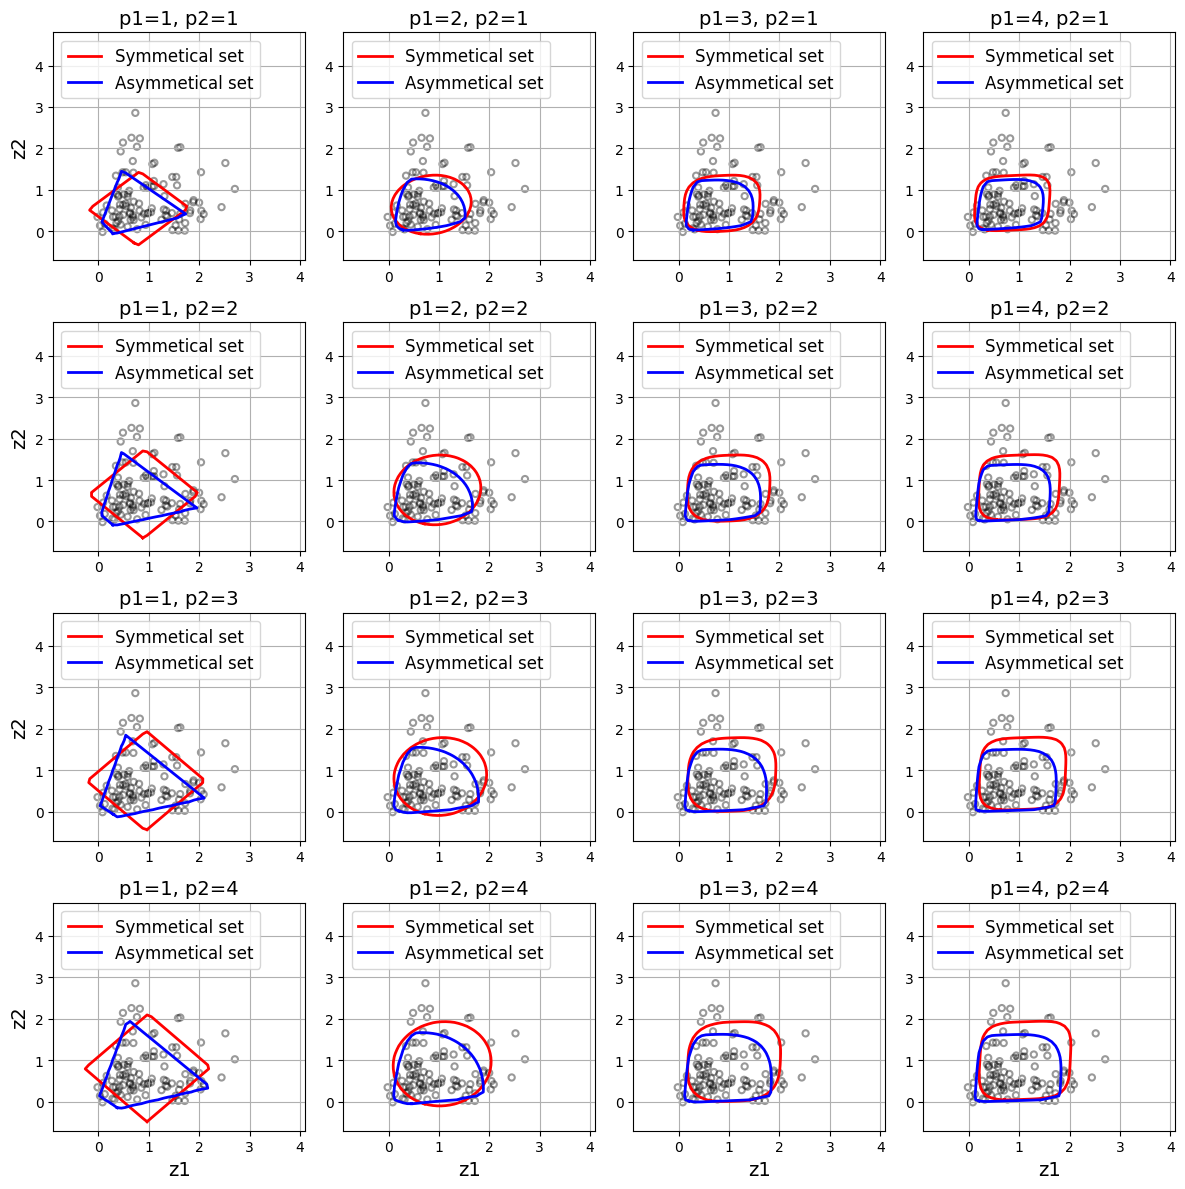

In [19]:
p1_values = range(1, 5)
p2_values = range(1, 5)

xlim = [-0.9, 4.1]
ylim = [-0.7, 4.8]
n1, n2 = 60, 60
z1 = np.linspace(xlim[0], xlim[1], n1)
z2 = np.linspace(ylim[0], ylim[1], n2)
zz1, zz2 = np.meshgrid(z1, z2)
zz = np.concatenate((zz1.flatten()[:, None],
                     zz2.flatten()[:, None]), axis=1)

fig, axes = plt.subplots(len(p1_values), len(p2_values), 
                         figsize=(len(p1_values)*3, len(p2_values)*3), dpi=100)
for i, p2 in enumerate(p2_values):
    for j, p1 in enumerate(p1_values):
        axes[i, j].scatter(zs[:, 0], zs[:, 1], s=20,
                           linewidth=1.5, color='none', edgecolor='k', alpha=0.4)

        q, Q = mvcs(zs, p1=p1, p2=p2, display=False)
        values = np.linalg.norm(zz@Q.T - q, ord=p1, axis=1).reshape(n2, n1)
        ct = axes[i, j].contour(zz1, zz2, (1/2)*(values)**p2, levels=[1])
        xydata= ct.allsegs[0][0].copy()
        ct.remove()
        axes[i, j].plot(xydata[:, 0], xydata[:, 1], linewidth=2, color='r', label='Symmetical set')
        qa, Qa, v1, v2 = mvcs_asymmetric(zs, r=None, p1=p1, p2=p2, max_iter=1000, tol=2e-3, display=False)
        inner = np.maximum((zz@Qa.T - qa)@np.diag(v1), 0) + np.maximum(-(zz@Qa.T - qa)@np.diag(v2), 0)
        values = np.linalg.norm(inner, ord=p1, axis=1).reshape(n2, n1)
        ct = axes[i, j].contour(zz1, zz2, (1/2)*(values)**p2, levels=[1], colors=['b'])
        xydata= ct.allsegs[0][0].copy()
        ct.remove()
        axes[i, j].plot(xydata[:, 0], xydata[:, 1], linewidth=2, color='b', label='Asymmetical set')
        axes[i, j].set_title(f'p1={p1}, p2={p2}', fontsize=14)
        axes[i, j].grid()
        axes[i, j].legend(loc='upper left', fontsize=12)
        
        if i == len(p2_values) - 1:
            axes[i, j].set_xlabel('z1', fontsize=14)
        if j == 0:
            axes[i, j].set_ylabel('z2', fontsize=14)
        axes[i, j].set_xlim(xlim)
        axes[i, j].set_ylim(ylim)
        
plt.tight_layout()
plt.show()

Particularly when $p_1=2$ and $p_2=1$, the following code plots the contours as the $\psi(\|\cdot\|)$ function takes $0.5$, $1.0$, and $1.5$. 

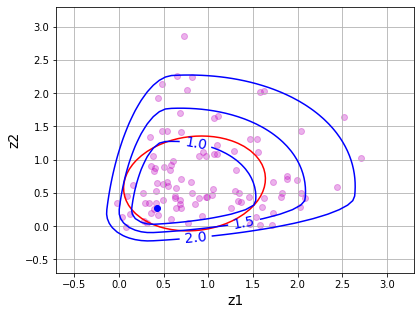

In [20]:
xlim = [-0.7, 3.3]
ylim = [-0.7, 3.3]
n1, n2 = 60, 60
z1 = np.linspace(xlim[0], xlim[1], n1)
z2 = np.linspace(ylim[0], ylim[1], n2)
zz1, zz2 = np.meshgrid(z1, z2)
zz = np.concatenate((zz1.flatten()[:, None],
                     zz2.flatten()[:, None]), axis=1)

p1 = 2
p2 = 1

plt.scatter(zs[:, 0], zs[:, 1], c='m', alpha=0.3)
q, Q = mvcs(zs, p1=p1, p2=p2, display=False)
values = np.linalg.norm(zz@Q.T - q, ord=2, axis=1).reshape(n2, n1)
ct = plt.contour(zz1, zz2, (1/2)*(values)**p2, levels=[1], colors=['r'])

qa, Qa, v1, v2 = mvcs_asymmetric(zs, p1=p1, p2=p2, tol=1e-2, display=False)
inner = np.maximum((zz@Qa.T - qa)@np.diag(v1), 0) + np.maximum(-(zz@Qa.T - qa)@np.diag(v2), 0)
values = np.linalg.norm(inner, ord=p1, axis=1).reshape(n2, n1)
ct = plt.contour(zz1, zz2, (1/2)*(values)**p2, levels=[1, 1.5, 2], colors=['b'])
plt.clabel(ct, ct.levels, inline=True, fontsize=14)
centroid = np.linalg.inv(Qa)@qa
plt.scatter(centroid[0], centroid[1], color='b')
plt.xlabel('z1', fontsize=14)
plt.ylabel('z2', fontsize=14)
plt.grid()
plt.show()

The centroid of the confidence set is highlighted as the blue point in the figure above, and the coordinate of the centroid is given below.

In [21]:
np.linalg.inv(Qa) @ qa

array([0.42103276, 0.27879445])

### Asymmetrical confidence set with side information

We generate the following training dataset.

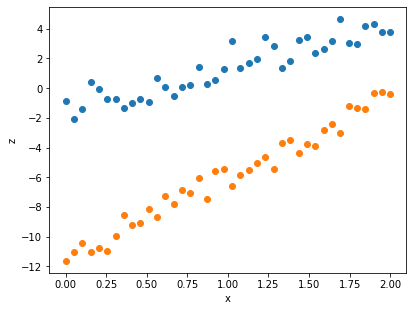

In [22]:
m = 40
L = 2
train = pd.DataFrame(np.linspace(0, 2, m), columns=['x'])
#train['z1'] = train['x'] ** 2
#train['z2'] = 1.5 * train['x'] ** 3 - 1
train['z1'] = 3*train['x'] - 2.5
train['z2'] = 5.5*train['x'] - 10.5
np.random.seed(0)
#error = np.random.multivariate_normal(np.zeros(2), np.array([[1, 0.5], [0.5, 1]]), size=m)
train['z1'] += stats.skewnorm.rvs(a=10, loc=0, scale=1, size=m)
train['z2'] -= stats.skewnorm.rvs(a=10, loc=0, scale=1, size=m)

plt.scatter(train['x'], train['z1'], label='z1')
plt.scatter(train['x'], train['z2'], label='z2')
plt.xlabel('x')
plt.ylabel('z')
plt.show()

In [23]:
zs = train[['z1', 'z2']].values
ss = train[['x']].values

In [24]:
#ss = np.concatenate((ss, np.log(train[['x']] + 0.1).values), axis=1)
#ss = np.concatenate((ss, (train[['x']] ** 0.5).values), axis=1)
#ss = np.concatenate((ss, np.random.randn(m)[:, None]), axis=1)

Then the asymmetrical confidence set with the side information `x` is estimated as follows.

In [25]:
p1, p2 = 2, 1

qa, Pa, Qa, v1, v2 = mvcs_asymmetric(zs, ss, p1=p1, p2=p2, tol=1e-3, display=False)
Da = np.linalg.inv(Qa)
Zhat = Da @ Pa
zhat0 = Da @ qa

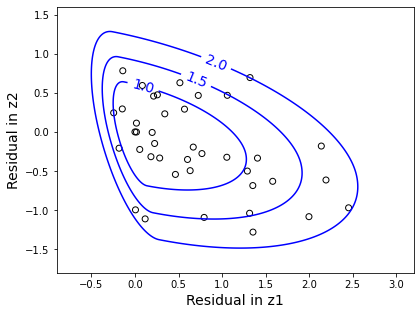

In [26]:
resid = zs - zhat0 - ss@Zhat.T
plt.scatter(resid[:, 0], resid[:, 1], color='none', edgecolor='k')

xlim = [-0.9, 3.2]
ylim = [-1.8, 1.6]
n1, n2 = 500, 500
z1 = np.linspace(xlim[0], xlim[1], n1)
z2 = np.linspace(ylim[0], ylim[1], n2)
zz1, zz2 = np.meshgrid(z1, z2)
zz = np.concatenate((zz1.flatten()[:, None],
                     zz2.flatten()[:, None]), axis=1)

inner = np.maximum(zz@Qa.T@np.diag(v1), 0) + np.maximum(-zz@Qa.T@np.diag(v2), 0)
values = np.linalg.norm(inner, ord=p1, axis=1).reshape(n2, n1)
ct = plt.contour(zz1, zz2, (1/2)*values**p2, levels=[1, 1.5, 2], colors=['b'])
plt.clabel(ct, ct.levels, inline=True, fontsize=14)
plt.xlabel('Residual in z1', fontsize=14)
plt.ylabel('Residual in z2', fontsize=14)
plt.show()

We then compare the asymmetrical results above with the symmetrical case.

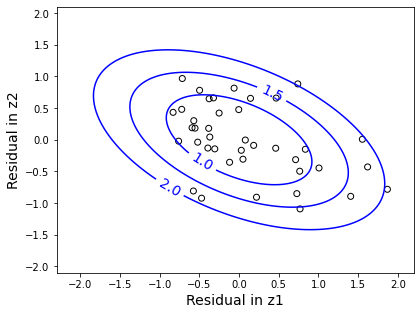

In [27]:
q, P, Q = mvcs(zs, ss, p1=p1, p2=p2, display=False)
D = np.linalg.inv(Q)
Zhat = D @ P
zhat0 = D @ q

resid = zs - zhat0 - ss@Zhat.T
plt.scatter(resid[:, 0], resid[:, 1], color='none', edgecolor='k')

xlim = [-2.3, 2.2]
ylim = [-2.1, 2.1]

n1, n2 = 200, 200
z1 = np.linspace(xlim[0], xlim[1], n1)
z2 = np.linspace(ylim[0], ylim[1], n2)
zz1, zz2 = np.meshgrid(z1, z2)
zz = np.concatenate((zz1.flatten()[:, None],
                     zz2.flatten()[:, None]), axis=1)

values = np.linalg.norm(zz@Q.T, ord=p1, axis=1).reshape(n2, n1)
ct = plt.contour(zz1, zz2, (1/2)*(values)**p2, levels=[1, 1.5, 2], colors=['b'])
plt.clabel(ct, ct.levels, inline=True, fontsize=14)
plt.xlabel('Residual in z1', fontsize=14)
plt.ylabel('Residual in z2', fontsize=14)
plt.show()

## Case Studies
### Parameters

In [7]:
I = 15
J = 30

np.random.seed(1)
xy = 10 * np.random.rand(2, I)

dist_list = []
for i in range(I):
    for j in range(i+1, I):
        dist_list.append((np.linalg.norm(xy[:,i] - xy[:,j]), (i, j)))
        
dist_list.sort()
arcs = [item[-1] for item in dist_list[:J]]

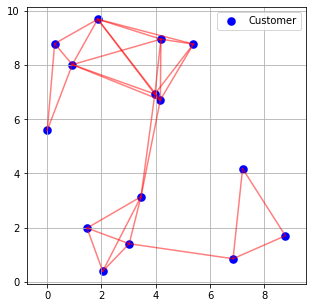

In [8]:
plt.figure(figsize=(5, 5))
for arc in arcs:
    i, j = arc
    plt.plot([xy[0,i], xy[0,j]], [xy[1,i], xy[1,j]], color='r', alpha=0.5)
plt.scatter(xy[0], xy[1], s=50, 
            color='b', edgecolor='b', linewidth=1.5, label='Customer')
plt.legend()
plt.grid()
plt.axis('equal')
plt.show()

In [9]:
d = np.linalg.norm((xy.T - np.array([5, 5])), axis=1)
c = 1 + d/5

In [10]:
def demand_samples(means, size):
    
    I = len(means)
    v = np.random.binomial(1, 0.05, size=(size, 1))
    
    return np.minimum(np.random.exponential(means, size=(size, I)) * (1 + v), 100)

In [11]:
Sin = 30
Sout = 1000

z_mean = 20 + 10*np.sin(2*np.pi*np.arange(1, I+1)/I)

np.random.seed(1)
zin = demand_samples(z_mean, 30)
zout = demand_samples(z_mean, 1000)

### Empirical model

The empirical model is formulated according to equation (EM).

$$
\begin{align}
Z_0 = \min~&\sum\limits_{i\in[I]}c_ix_i \\
\text{s.t.}~&\sum\limits_{j\in\mathcal{I}_i}y_{\omega ij} \leq x_i &\forall i\in[I], \omega\in[\Omega] \\
&z_{\omega j}\leq \sum\limits_{i\in\mathcal{S}_j}y_{\omega ij} &\forall j\in[I], \omega\in[\Omega] \\
&\pmb{x}\in\mathbb{R}_+^{I}, \pmb{y}\in\mathbb{R}_+^{\Omega\times \mathcal{A}}
\end{align}
$$

In [12]:
def em_decision(c, arcs, xbar, zin, display=True):
    
    S, I = zin.shape
    
    ij= np.array([(i, i) for i in range(I)] + 
                 arcs + [a[::-1] for a in arcs])
    K = ij.shape[0]
    
    model = ro.Model()
    x = model.dvar(I)
    y = model.dvar((S, K))
    
    model.min(c @ x)
    
    for s in range(S):
        for i in range(I):
            model.st(y[s, ij[:, 0] == i].sum() <= x[i])
            model.st(zin[s, i] <= y[s, ij[:, 1] == i].sum())
    
    model.st(x >= 0, x <= xbar, y >= 0)
    
    model.solve(cpt, display=display)
    
    return model.get(), x.get()

### Robust optimization model

The model solves a robust optimization model when the budget of uncertainty is specified by the input argument `gamma`. See equation (30).

In [13]:
def ro_decision(c, arcs, xbar, Q, q, gamma, p1=2, vs=None, display=True):
    
    I = len(c)
    if vs is None:
        v1, v2 = 1, 1
    else:
        v1, v2 = vs
    
    ij= np.array([(i, i) for i in range(I)] + 
                 arcs + [a[::-1] for a in arcs])
    K = ij.shape[0]
    
    model = ro.Model()
    z = model.rvar(I)
    w1 = model.rvar(I)
    w2 = model.rvar(I)
    zset = (w1 - w2 == Q@z - q,
            rso.norm(v1*w1 + v2*w2, p1) <= gamma,
            w1 >= 0, w2 >= 0,
            z >= 0, z <= 100)
    
    x = model.dvar(I)
    
    y = model.ldr(K)
    y.adapt(w1)
    y.adapt(w2)
    
    model.minmax(c @ x, zset)
    
    for i in range(I):
        model.st(y[ij[:, 0] == i].sum() <= x[i])
        model.st(z[i] - y[ij[:, 1] == i].sum() <= 0)
    
    model.st(x >= 0, x <= xbar, y >= 0)
    
    model.solve(cpt, display=display)
    
    return model.get(), x.get()

The function below solves the robust optimization model via a bisection algorithm so that the total cost of the optimal decision is close to a given target `tau`. 

In [14]:
def ro_bisection(c, arcs, xbar, Q, q, tau, p1=2, vs=None, tol=1e-3, display=True):
    
    pv = p1[0]/p1[1] if isinstance(p1, tuple) else p1
    L = len(c)
    gamma_upper = 2 * L**(1/pv)
    gamma_lower = 0
    
    while gamma_upper - gamma_lower > tol:
        gamma = (gamma_upper + gamma_lower) / 2
        
        Zr, x = ro_decision(c, arcs, xbar, Q, q, gamma, p1, vs, display=display)
        
        if Zr < tau:
            gamma_lower = gamma
        else:
            gamma_upper = gamma
    
    return gamma, x

### Robust satisficing model

The model below is formulated based on equation (31). The difference is that the decision rule `y` also adapts to the lifted random variable `u`.

In [15]:
def rs_decision(c, arcs, xbar, Q, q, tau, gbar, p1=2, vs=None, display=True):
    
    I = len(c)
    if vs is None:
        v1, v2 = 1, 1
    else:
        v1, v2 = vs
    
    ij= np.array([(i, i) for i in range(I)] + 
                 arcs + [a[::-1] for a in arcs])
    K = ij.shape[0]
    
    model = ro.Model()
    z = model.rvar(I)
    w1 = model.rvar(I)
    w2 = model.rvar(I)
    u = model.rvar()
    zset = (w1 - w2 == Q@z - q,
            rso.norm(v1*w1 + v2*w2, p1) <= u,
            u <= gbar,
            w1 >= 0, w2 >= 0,
            z >= 0, z <= 100)
    
    x = model.dvar(I)
    kappa = model.dvar()
    
    y = model.ldr(K)
    y.adapt(w1)
    y.adapt(w2)
    y.adapt(u)
    
    model.minmax(kappa, zset)
    model.st(c @ x <= tau)
    
    for i in range(I):
        model.st(y[ij[:, 0] == i].sum() <= x[i])
        model.st(z[i] - y[ij[:, 1] == i].sum() <= kappa * u)
    
    model.st(x >= 0, x <= xbar, y >= 0)
    
    model.solve(cpt, display=display)
    
    return model.get(), x.get()#, (y.get(), y.get(w1), y.get(w2), y.get(u))

### Simulation

The function below evaluate the performance of a decision `x` under the uncertainty represented by out-of-sample `zout`. 

In [16]:
def one_sim(arcs, x, zs):
    
    I = x.shape[0]
    
    ij= np.array([(i, i) for i in range(I)] + 
                 arcs + [a[::-1] for a in arcs])
    K = ij.shape[0]
    
    model = ro.Model()
    s = model.dvar(I)
    y = model.dvar(K)
    
    model.min(s.sum())
    for i in range(I):
        model.st(y[ij[:, 0] == i].sum() <= x[i])
        model.st(zs[i] - y[ij[:, 1] == i].sum() <= s[i])
    model.st(y >= 0, s >= 0)
    
    model.solve(cpt, display=False)
    
    return model.get()

def multi_sim(arcs, x, zout, n_jobs=10):
    
    with Pool(n_jobs) as p:
        params = [[arcs, x, zout[s]] for s in range(len(zout))]
        inf = p.starmap(one_sim, params)
    
    return np.array(inf)

### Empirical and satisficing modes under the same training data and cost budget

In the following experiments:

1. The empirical models are solved under different training datasets to achieve the total cost budget $Z_0$ and the optimal solutions are evaluated using simulation to find out the violation of constraints.

2. The satisficing models are solved under the same training datasets and cost budget $Z_0$, then the optimal solutions are evaluated using simulation with the same out-of-sample data.

3. The performance of two models is compared in terms of 1) the average of the total violation; and 2) the probability of violation occurrences. The blue lines indicate the satisficing models have better performance, and the red lines indicate worse performance. 

In [55]:
def solve_em_rs(c, arcs, xbar, ps, zin):
    
    Sin, Sout = zin.shape[0], zout.shape[0]
    
    em_infs = np.zeros(Sout)
    rs_x = {p1: np.zeros(I) for p1 in ps}
    rs_infs = {p1: np.zeros((Sout)) for p1 in ps}
    
    Z0, x = em_decision(c, arcs, xbar, zin, display=False)
    #for s in range(Sout):
    #    em_infs[s] = one_sim(arcs, x, zout[s])
    em_x = x
    em_cost = Z0
    
    for p1 in ps:
        pv = p1[0]/p1[1] if isinstance(p1, tuple) else p1
        #print(pv, zin.shape)
        q, Q = mvcs(zin, p1=p1, p2=p1, display=False)
    
    """
    for p1 in ps:
        pv = p1[0]/p1[1] if isinstance(p1, tuple) else p1
        q, Q = mvcs(zin, p1=p1, p2=p1, display=False)
        gbar = np.linalg.norm(zin@Q - q, pv, axis=1).max()
        kappa, x = rs_decision(c, arcs, xbar, Q, q, Z0, gbar, p1=p1, display=False)
        #for s in range(Sout):
        #    rs_infs[p1][s] = one_sim(arcs, x, zout[s])
        #    rs_x[p1] = x
    
    return [em_cost, em_x, rs_x]
            #'rs_infs': rs_infs}
    """
    
    return {'Z0': em_cost, 
            'em_sol': em_x}

In [56]:
repeats = 8              # Number of repetitions
Sout = 2000
Sin = 50

ps = [1]
np.random.seed(0)
zout = demand_samples(z_mean, Sout)
zins = [demand_samples(z_mean, Sin) for r in range(repeats)]

results = []
with Pool(5) as p:
    params = [(c, arcs, 200, ps, zins[r]) for r in range(repeats)]
    for param in params:
        results.append(p.apply(solve_em_rs, param))

KeyboardInterrupt: 

In [68]:
param

(array([1.3791808 , 1.47066497, 2.00663824, 1.82071668, 1.9293527 ,
        2.01318333, 2.12730042, 1.4844049 , 1.43655443, 1.75677086,
        1.80559033, 1.90883347, 2.09511454, 2.00396165, 2.21054408]),
 [(0, 8),
  (5, 14),
  (9, 10),
  (3, 12),
  (3, 4),
  (4, 12),
  (3, 7),
  (6, 14),
  (5, 6),
  (8, 10),
  (11, 13),
  (0, 10),
  (4, 7),
  (8, 9),
  (0, 9),
  (6, 10),
  (2, 5),
  (1, 13),
  (7, 12),
  (2, 14),
  (5, 8),
  (1, 11),
  (5, 10),
  (6, 8),
  (0, 5),
  (0, 7),
  (6, 9),
  (0, 6),
  (7, 8),
  (3, 11)],
 200,
 [1],
 array([[2.15564507e+01, 2.03749483e+01, 1.98373684e+00, 3.51352418e+01,
         1.51951606e+01, 1.03392900e+01, 1.23095375e-01, 6.30271453e+00,
         1.49376003e+01, 1.27694139e+01, 3.92380721e-01, 1.96093743e+00,
         2.23010866e+01, 3.02117385e+00, 2.51353292e+01],
        [2.00152119e+01, 9.40102883e+00, 1.00000000e+02, 2.35594199e+01,
         5.47274651e+01, 2.89426508e+01, 1.87934027e+00, 8.72793953e+00,
         5.43753576e+00, 7.39783199e+00, 2

In [79]:
zins[0]

array([[2.15564507e+01, 2.03749483e+01, 1.98373684e+00, 3.51352418e+01,
        1.51951606e+01, 1.03392900e+01, 1.23095375e-01, 6.30271453e+00,
        1.49376003e+01, 1.27694139e+01, 3.92380721e-01, 1.96093743e+00,
        2.23010866e+01, 3.02117385e+00, 2.51353292e+01],
       [2.00152119e+01, 9.40102883e+00, 1.00000000e+02, 2.35594199e+01,
        5.47274651e+01, 2.89426508e+01, 1.87934027e+00, 8.72793953e+00,
        5.43753576e+00, 7.39783199e+00, 2.96045516e+00, 2.61488488e+00,
        2.86084182e+00, 1.50610387e+01, 4.12450275e+01],
       [2.82985008e+00, 5.74215756e+00, 2.54844460e+01, 3.04773773e+01,
        7.66846364e+00, 4.79572646e+00, 1.00653019e+01, 5.15375949e+00,
        5.49814969e+00, 7.28691863e+00, 3.65023438e+00, 3.32960930e+01,
        5.62430239e+00, 4.84743290e+00, 4.06427477e+01],
       [2.36552345e+01, 9.36574205e-01, 5.88201206e+00, 1.85889690e+01,
        3.93555597e+01, 8.92662734e+01, 8.37873986e+00, 1.08346522e+01,
        9.06865899e+00, 3.81866536e+0

In [42]:
results

[{'Z0': 994.982795657002,
  'em_sol': array([123.3331469 , 130.84497656, 108.78628593,  14.31998359,
           0.        ,  34.57152601,   0.        , 176.06428913,
           0.        ,   0.        ,   0.        ,  29.93351599,
           0.        ,   0.        ,   0.        ])},
 {'Z0': 1104.081603938391,
  'em_sol': array([200.        , 123.49915018,  84.07285102,   1.38164533,
           0.        ,  56.36560133,   0.        , 178.75273819,
          27.12744425,   0.        ,   0.        ,  30.18304602,
           0.        ,   0.        ,   0.        ])},
 {'Z0': 1069.3410490096485,
  'em_sol': array([141.28838724, 114.38832497, 159.08606739,  10.91199314,
           0.        ,  34.36617312,   0.        , 197.32987744,
           0.        ,   0.        ,   0.        ,   2.64729158,
           0.        ,   0.        ,   0.        ])},
 {'Z0': 1084.8717601068092,
  'em_sol': array([200.        , 113.32520277, 157.11592167,  22.99630386,
           0.        ,   0.        ,   

In [43]:
params

[[array([1.3791808 , 1.47066497, 2.00663824, 1.82071668, 1.9293527 ,
         2.01318333, 2.12730042, 1.4844049 , 1.43655443, 1.75677086,
         1.80559033, 1.90883347, 2.09511454, 2.00396165, 2.21054408]),
  [(0, 8),
   (5, 14),
   (9, 10),
   (3, 12),
   (3, 4),
   (4, 12),
   (3, 7),
   (6, 14),
   (5, 6),
   (8, 10),
   (11, 13),
   (0, 10),
   (4, 7),
   (8, 9),
   (0, 9),
   (6, 10),
   (2, 5),
   (1, 13),
   (7, 12),
   (2, 14),
   (5, 8),
   (1, 11),
   (5, 10),
   (6, 8),
   (0, 5),
   (0, 7),
   (6, 9),
   (0, 6),
   (7, 8),
   (3, 11)],
  200,
  [1],
  array([[2.15564507e+01, 2.03749483e+01, 1.98373684e+00, 3.51352418e+01,
          1.51951606e+01, 1.03392900e+01, 1.23095375e-01, 6.30271453e+00,
          1.49376003e+01, 1.27694139e+01, 3.92380721e-01, 1.96093743e+00,
          2.23010866e+01, 3.02117385e+00, 2.51353292e+01],
         [2.00152119e+01, 9.40102883e+00, 1.00000000e+02, 2.35594199e+01,
          5.47274651e+01, 2.89426508e+01, 1.87934027e+00, 8.72793953e+00,
 

In [38]:
repeats = 20              # Number of repetitions
Sout = 2000
Sin = 50

np.random.seed(0)
zout = demand_samples(z_mean, Sout)

em_xs = np.zeros((repeats, I))
em_infs = np.zeros((repeats, Sout))
em_costs = np.zeros(repeats)
ps = [1, (3, 2), 2, (5, 2), 3]
rs_xs = {p1: np.zeros((repeats, I)) for p1 in ps}
rs_infs = {p1: np.zeros((repeats, Sout)) for p1 in ps}
zin_sets = []
for r in range(repeats):
    zin = demand_samples(z_mean, Sin)
    zin_sets.append(zin)
    
    Z0, x = em_decision(c, arcs, 200, zin, display=False)
    em_costs[r] = Z0
    inf = multi_sim(arcs, x, zout)   
    em_infs[r]  = inf
    em_xs[r] = x
    
    print(f'Repeat {r}: first-stage cost: {Z0}')
    print('-------------------------------------------------------------------------')
    print(f'EM average total violation:                {em_infs[r].mean()}')
    for p1 in ps:
        pv, sp = (p1[0]/p1[1], '') if isinstance(p1, tuple) else (p1, '  ')
        q, Q = mvcs(zin, p1=p1, p2=p1, display=False)
        gbar = np.linalg.norm(zin@Q - q, pv, axis=1).max()
        kappa, x = rs_decision(c, arcs, 200, Q, q, Z0, gbar, p1=p1, display=False)
        inf = multi_sim(arcs, x, zout)
        rs_infs[p1][r] = inf
        rs_xs[p1][r] = x
    
        print(f'RS with l{pv}-norm average total violation: {sp}{rs_infs[p1][r].mean()}')
    
    print('\n')

Repeat 0: first-stage cost: 994.982795657002
-------------------------------------------------------------------------
EM average total violation:                2.38425868926995
RS with l1-norm average total violation:   2.1869414904621935
RS with l1.5-norm average total violation: 2.940068214172564
RS with l2-norm average total violation:   2.2029950326235035
RS with l2.5-norm average total violation: 2.495379443772682
RS with l3-norm average total violation:   2.466612497426065


Repeat 1: first-stage cost: 1104.081603938391
-------------------------------------------------------------------------
EM average total violation:                1.2166443065900419
RS with l1-norm average total violation:   0.9941613940392738
RS with l1.5-norm average total violation: 1.1839831894250852
RS with l2-norm average total violation:   0.9423940931726992
RS with l2.5-norm average total violation: 1.1684867872757554
RS with l3-norm average total violation:   1.2086453827452275


Repeat 2: first-st

RS with l2.5-norm average total violation: 9.929671534635565
RS with l3-norm average total violation:   9.202315518503667


Repeat 17: first-stage cost: 1124.9701690344946
-------------------------------------------------------------------------
EM average total violation:                1.42814347426555
RS with l1-norm average total violation:   0.8053269386826203
RS with l1.5-norm average total violation: 1.2928545709911055
RS with l2-norm average total violation:   0.789372052926691
RS with l2.5-norm average total violation: 1.2528410128805905
RS with l3-norm average total violation:   1.0763441152238447


Repeat 18: first-stage cost: 801.0077355147137
-------------------------------------------------------------------------
EM average total violation:                7.7028417706398615
RS with l1-norm average total violation:   7.880837027843729
RS with l1.5-norm average total violation: 11.904449706668863
RS with l2-norm average total violation:   8.34725402539986
RS with l2.5-norm

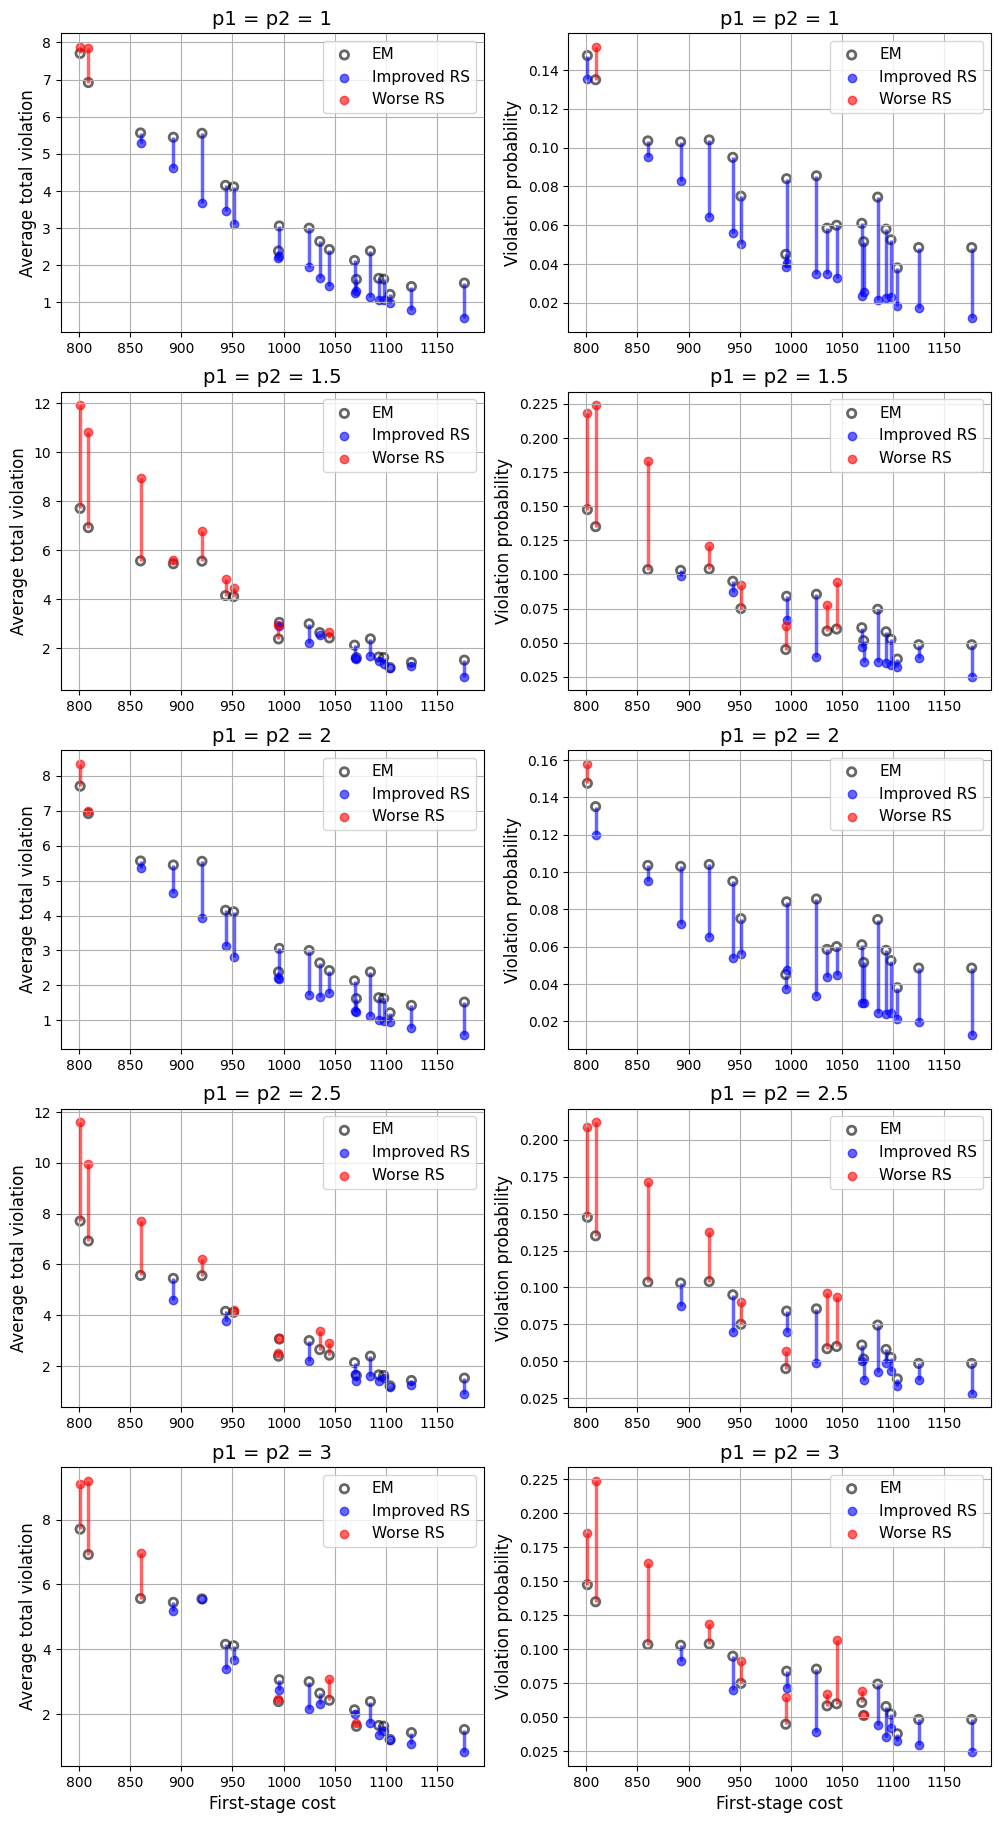

In [39]:
rows = len(ps)

em_inf_mean = em_infs.mean(axis=1)
em_inf_prob = (em_infs > 0).mean(axis=1)

fig, axes = plt.subplots(rows, 2, figsize=(12, 4.5*rows), dpi=100)

for r, p1 in enumerate(ps):
    pv = p1[0]/p1[1] if isinstance(p1, tuple) else p1
    
    rs_inf_mean = rs_infs[p1].mean(axis=1)
    axes[r, 0].scatter(em_costs, em_inf_mean , color='none', edgecolor='k', linewidth=2, alpha=0.6, label='EM')
    diff = em_inf_mean - rs_inf_mean
    improve = diff > 0
    axes[r, 0].scatter(em_costs[improve], rs_inf_mean[improve], color='b', alpha=0.6, label=f'Improved RS')
    axes[r, 0].scatter(em_costs[~improve], rs_inf_mean[~improve], color='r', alpha=0.6, label=f'Worse RS')
    axes[r, 0].vlines(em_costs[improve], em_inf_mean[improve], rs_inf_mean[improve], 
                      color='b', linewidth=2.5, alpha=0.6)
    axes[r, 0].vlines(em_costs[~improve], em_inf_mean[~improve], rs_inf_mean[~improve], 
                      color='r', linewidth=2.5, alpha=0.6)
    if r == len(ps) - 1:
        axes[r, 0].set_xlabel('First-stage cost', fontsize=12)
    axes[r, 0].set_ylabel('Average total violation', fontsize=12)
    axes[r, 0].legend(loc='upper right', fontsize=11)
    axes[r, 0].grid()
    axes[r, 0].set_title(f'p1 = p2 = {pv}', fontsize=14)
    
    rs_inf_prob = (rs_infs[p1] > 0).mean(axis=1)
    axes[r, 1].scatter(em_costs, em_inf_prob , color='none', edgecolor='k', linewidth=2, alpha=0.6, label='EM')
    diff = em_inf_prob - rs_inf_prob
    improve = diff > 0
    axes[r, 1].scatter(em_costs[improve], rs_inf_prob[improve], color='b', alpha=0.6, label=f'Improved RS')
    axes[r, 1].scatter(em_costs[~improve], rs_inf_prob[~improve], color='r', alpha=0.6, label=f'Worse RS')
    axes[r, 1].vlines(em_costs[improve], em_inf_prob[improve], rs_inf_prob[improve], 
                      color='b', linewidth=2.5, alpha=0.6)
    axes[r, 1].vlines(em_costs[~improve], em_inf_prob[~improve], rs_inf_prob[~improve], 
                      color='r', linewidth=2.5, alpha=0.6)
    if r == len(ps) - 1:
        axes[r, 1].set_xlabel('First-stage cost', fontsize=12)
    axes[r, 1].set_ylabel('Violation probability', fontsize=12)
    axes[r, 1].legend(loc='upper right', fontsize=11)
    axes[r, 1].grid()
    axes[r, 1].set_title(f'p1 = p2 = {pv}', fontsize=14)

plt.show()

### Empirical, robust optimization, and satisficing modes under the same training data and varying cost budgets

In the experiments below:

1. The average total cost from the previous section is calculated.

2. The robust optimization models and satisficing models are solved respectively under the training datasets generated before, while the cost budgets vary from 80% to 130% of the average total cost.

3. The performance of the robust and satisficing models are evaluated under the same out-of-sample data via simulation. 

4. The performance of these three models are visualized. Because the robust and satisficing models are assessed under different training datasets, we also plot the margin between the 5th-percentile and 95th-percentile for the violation performance. 

In [42]:
avg_cost = em_costs.mean()

B = 11
ratios = np.linspace(0.8, 1.3, B)
ps = [1, (3, 2), 2]

rs_xs = {p1: np.zeros((B, repeats, I)) for p1 in ps}
rs_infs = {p1: np.zeros((B, repeats, Sout)) for p1 in ps}

ro_xs = {p1: np.zeros((B, repeats, I)) for p1 in ps}
ro_infs = {p1: np.zeros((B, repeats, Sout)) for p1 in ps}
for r, zin in enumerate(zin_sets):
    print(f'Repeat {r} ... \n')
    for p1 in ps:
        pv, sp = (p1[0]/p1[1], '') if isinstance(p1, tuple) else (p1, '  ')
        q, Q = mvcs(zin, p1=p1, p2=p1, display=False)
        gbar = np.linalg.norm(zin@Q - q, pv, axis=1).max()
        for j, t in enumerate(ratios):
            tau = avg_cost * t
            kappa, x = rs_decision(c, arcs, 200, Q, q, tau, gbar, 
                                   p1=p1, display=False)
            inf = multi_sim(arcs, x, zout)
            rs_infs[p1][j, r] = inf
            rs_xs[p1][j, r] = x
            
            gamma, x = ro_bisection(c, arcs, 200, Q, q, tau, 
                                    p1=p1, tol=1e-3, display=False)
            inf = multi_sim(arcs, x, zout)
            ro_infs[p1][j, r] = inf
            ro_xs[p1][j, r] = x

Repeat 0 ... 

Repeat 1 ... 

Repeat 2 ... 

Repeat 3 ... 

Repeat 4 ... 

Repeat 5 ... 

Repeat 6 ... 

Repeat 7 ... 

Repeat 8 ... 

Repeat 9 ... 

Repeat 10 ... 

Repeat 11 ... 

Repeat 12 ... 

Repeat 13 ... 

Repeat 14 ... 

Repeat 15 ... 

Repeat 16 ... 

Repeat 17 ... 

Repeat 18 ... 

Repeat 19 ... 



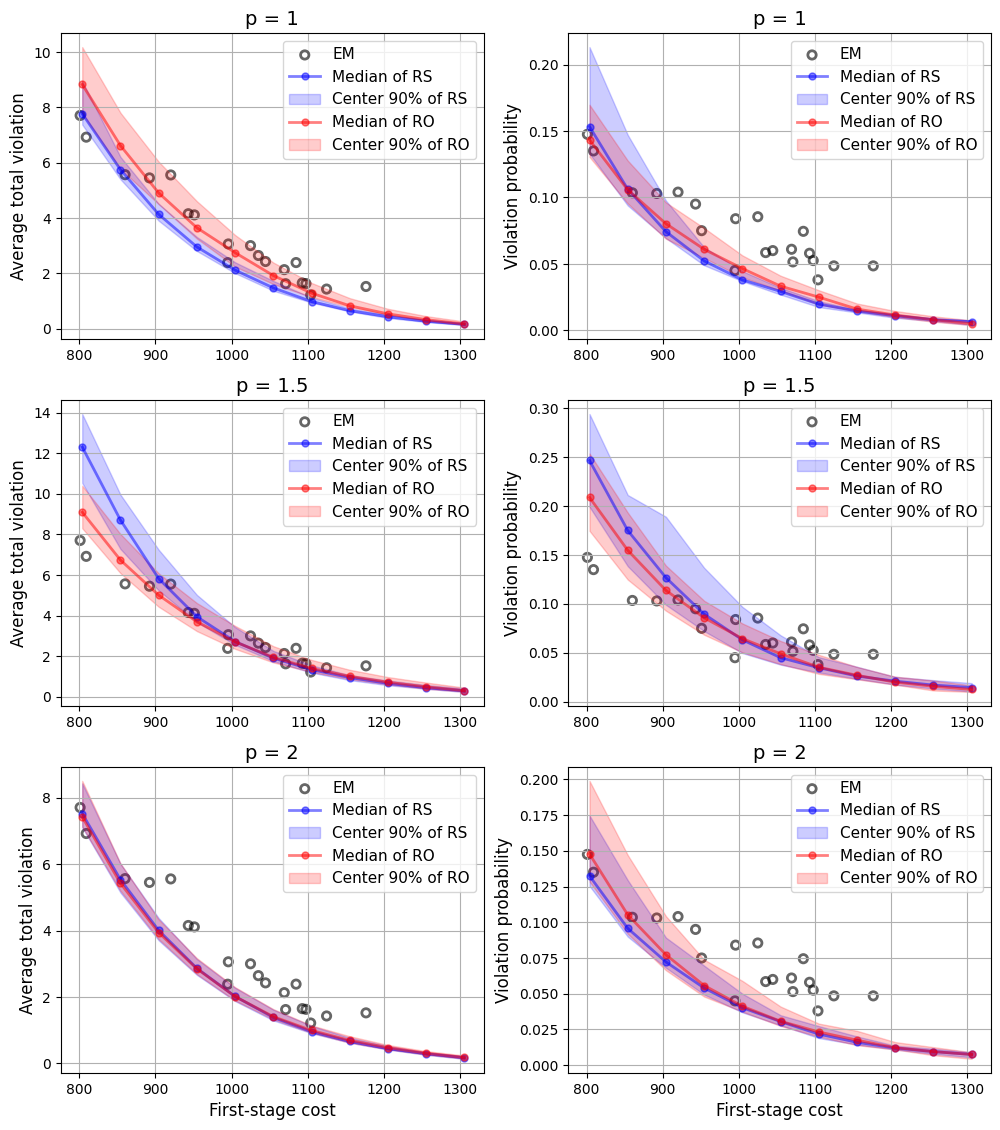

In [49]:
rows = len(ps)

em_inf_mean = em_infs.mean(axis=1)
em_inf_prob = (em_infs > 0).mean(axis=1)

fig, axes = plt.subplots(rows, 2, figsize=(12, 4.5*rows), dpi=100)

for r, p1 in enumerate(ps):
    pv = p1[0]/p1[1] if isinstance(p1, tuple) else p1
    
    axes[r, 0].scatter(em_costs, em_inf_mean , color='none', edgecolor='k', linewidth=2, alpha=0.6, label='EM')
    rs_inf_center = np.median(rs_infs[p1].mean(axis=2), axis=1)
    axes[r, 0].plot(ratios*avg_cost, rs_inf_center, 
                    markersize=5, marker='o', linewidth=2, color='b', alpha=0.5, 
                    label='Median of RS')
    upper = np.quantile(rs_infs[p1].mean(axis=2), 0.95, axis=1)
    lower = np.quantile(rs_infs[p1].mean(axis=2), 0.05, axis=1)
    axes[r, 0].fill_between(ratios*avg_cost, lower, upper, color='b', alpha=0.2, label='Center 90% of RS')
    ro_inf_center = np.median(ro_infs[p1].mean(axis=2), axis=1)
    axes[r, 0].plot(ratios*avg_cost, ro_inf_center, 
                    markersize=5, marker='o', linewidth=2, color='r', alpha=0.5, 
                    label='Median of RO')
    upper = np.quantile(ro_infs[p1].mean(axis=2), 0.95, axis=1)
    lower = np.quantile(ro_infs[p1].mean(axis=2), 0.05, axis=1)
    axes[r, 0].fill_between(ratios*avg_cost, lower, upper, color='r', alpha=0.2, label='Center 90% of RO')
    
    if r == len(ps) - 1:
        axes[r, 0].set_xlabel('First-stage cost', fontsize=12)
    axes[r, 0].set_ylabel('Average total violation', fontsize=12)
    axes[r, 0].legend(loc='upper right', fontsize=11)
    axes[r, 0].grid()
    axes[r, 0].set_title(f'p = {pv}', fontsize=14)
    
    axes[r, 1].scatter(em_costs, em_inf_prob , color='none', edgecolor='k', linewidth=2, alpha=0.6, label='EM')
    rs_inf_prob = np.median((rs_infs[p1] > 0).mean(axis=2), axis=1)
    axes[r, 1].plot(ratios*avg_cost, rs_inf_prob, 
                    markersize=5, marker='o', linewidth=2, color='b', alpha=0.5, 
                    label='Median of RS')
    upper = np.quantile((rs_infs[p1] > 0).mean(axis=2), 0.95, axis=1)
    lower = np.quantile((rs_infs[p1] > 0).mean(axis=2), 0.05, axis=1)
    axes[r, 1].fill_between(ratios*avg_cost, lower, upper, color='b', alpha=0.2, label='Center 90% of RS')
    ro_inf_prob = np.median((ro_infs[p1] > 0).mean(axis=2), axis=1)
    axes[r, 1].plot(ratios*avg_cost, ro_inf_prob, 
                    markersize=5, marker='o', linewidth=2, color='r', alpha=0.5,
                    label='Median of RO')
    upper = np.quantile((ro_infs[p1] > 0).mean(axis=2), 0.95, axis=1)
    lower = np.quantile((ro_infs[p1] > 0).mean(axis=2), 0.05, axis=1)
    axes[r, 1].fill_between(ratios*avg_cost, lower, upper, color='r', alpha=0.2, label='Center 90% of RO')
    
    if r == len(ps) - 1:
        axes[r, 1].set_xlabel('First-stage cost', fontsize=12)
    axes[r, 1].set_ylabel('Violation probability', fontsize=12)
    axes[r, 1].legend(loc='upper right', fontsize=11)
    axes[r, 1].grid()
    axes[r, 1].set_title(f'p = {pv}', fontsize=14)

plt.show()

In [48]:
np.mean(rs_infs[2].mean(axis=2), axis=1)

array([7.6534841 , 5.587266  , 4.03746199, 2.8851896 , 2.03860065,
       1.41703538, 0.98607587, 0.67868862, 0.46002233, 0.29728399,
       0.17692353])